# Federated Learning Pipeline

This annotated notebook explains the pipeline **step by step**, with:
- short introductions before each code cell;
- comments at the top of every cell describing *what it does* and *how to check the result*;
- a **checklist**, **troubleshooting tips**, a **glossary**, and suggested exercises.

> **Learning Objectives**
> - Understand the end‑to‑end flow of a Federated Learning (FL) pipeline: preprocessing → training → evaluation → saving artifacts.
> - Learn to read and adapt components (dataset, model, training loop, metrics).
> - Run experiments (saving results).

> **Prerequisites**
> - Intermediate Python; experience with PyTorch and scikit‑learn.
> - Basic ML concepts: train/val/test split, overfitting, metrics.
> - Introductory knowledge of FL (clients, server/aggregator, training rounds).

> **Mini Glossary (FL)**
> - **Client**: A device/site (e.g., hospital, phone) that trains locally on private data.
> - **Server**:The coordinator distributes the starting model, communicates with clients, collects client updates, and distributes new models.
> - **Aggregator/Aggregation Method**:  Method chosen to aggregate all client models and create the new global model.
> - **Round**: One cycle of local training → sending updates → aggregation.
> - **Aggregation frequency**: Number of epochs between sending weights to the server.
> - **Federated Averaging (FedAvg)**: Standard method to average/aggregate client model weights.
> - **IID Data**: Customer data follows the same distribution across all clients (homogeneity).
> - **Non‑IID Data**: Client data may follow different distributions (heterogeneity).
> - **Global model**: Model sent by the server to all clients
> - **Local model**: Model trained by the client on its data

### What does the next cell do?
**Environment setup and library imports.**

In [25]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from copy import deepcopy

#### Definition of the model, train function, and evaluation.

In [26]:
# Model definition
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=64):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Training and evaluation loops
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    for features, labels in loader:
        features, labels = features.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(DEVICE), labels.to(DEVICE)
            outputs = model(features)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

#### Data loading and preprocessing

In [27]:
def load_dataset(train_file, test_file):
    # Load data
    train_data = pd.read_csv(train_file)
    test_data = pd.read_csv(test_file)
    
    class_names = train_data["Outcome"].unique()
    print(f"Classes: {class_names}")
    
    # EXCLUDE identifier columns only
    exclude_columns = ['PatientID', 'CenterID', 'Outcome']
    
    # Handle categorical columns (like Gender)
    data_combined = pd.concat([train_data, test_data])
    
    # Encode Gender: M=0, F=1
    if 'Gender' in data_combined.columns:
        data_combined['Gender'] = data_combined['Gender'].map({'M': 0, 'F': 1})
        # Fill any missing values with 0 (Male)
        data_combined['Gender'] = data_combined['Gender'].fillna(0)
    
    # Split back into train and test
    train_data_encoded = data_combined[:len(train_data)]
    test_data_encoded = data_combined[len(train_data):]
    
    # Get feature names (exclude identifiers)
    feature_names = [col for col in train_data_encoded.columns if col not in exclude_columns]
    
    print(f"Number of features: {len(feature_names)}")
    print(f"First few features: {feature_names[:5]}")
    
    X_train = train_data_encoded[feature_names].values
    y_train = train_data_encoded["Outcome"].values
    X_test = test_data_encoded[feature_names].values  
    y_test = test_data_encoded["Outcome"].values
    
    # Split training data into training and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )
    
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")
    
    input_dim = X_train.shape[1]
    output_dim = len(class_names)

    return X_train, y_train, X_val, y_val, X_test, y_test, input_dim, output_dim

def features_scaling(X_train, X_val, X_test):
    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    print("Features scaled successfully.")
    return X_train_scaled, X_val_scaled, X_test_scaled


def convert_to_tensors(X_train, y_train, X_val, y_val, X_test, y_test):
    # Convert to PyTorch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    return X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, X_test_tensor, y_test_tensor

def create_dataloader(X_tensor, y_tensor, batch_size):
    # Create DataLoader objects
    data = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(data, batch_size=batch_size, shuffle=True)
    return loader



#### Hyperparameters


In [28]:
HIDDEN_DIM = 64
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 1e-3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
PATIENCE = 5  # Early stopping patience

### Pipeline execution

Data loading and data loader creation.

In [29]:
# Load and preprocess server data
X_train_server, y_train_server, X_val_server, y_val_server, X_test_server, y_test_server, INPUT_DIM, OUTPUT_DIM = load_dataset(
    "C:/VSCode_Projects/E-Health/E-Health_Project/EHealthProject/project/federatedLearning/health_data_backup/train_health_data_server.csv", "C:/VSCode_Projects/E-Health/E-Health_Project/EHealthProject/project/federatedLearning/health_data_backup/test_health_data_server.csv")

X_train_server, X_val_server, X_test_server = features_scaling(X_train_server, X_val_server, X_test_server)

X_train_tensor_server, y_train_tensor_server, X_val_tensor_server, y_val_tensor_server, X_test_tensor_server, y_test_tensor_server = convert_to_tensors(X_train_server, y_train_server, X_val_server, y_val_server, X_test_server, y_test_server)

train_loader_server = create_dataloader(X_train_tensor_server, y_train_tensor_server, BATCH_SIZE)
val_loader_server = create_dataloader(X_val_tensor_server, y_val_tensor_server, BATCH_SIZE)
test_loader_server = create_dataloader(X_test_tensor_server, y_test_tensor_server, BATCH_SIZE)

print(f"Device: {DEVICE}, Input dim: {INPUT_DIM}, Output dim: {OUTPUT_DIM}")

Classes: [1 0]
Number of features: 187
First few features: ['Gender', 'Tobacco', 'Alcohol', 'Performance status', 'Surgery']
Training samples: 933, Validation samples: 234, Test samples: 292
Features scaled successfully.
Device: cpu, Input dim: 187, Output dim: 2


#### Server training

In [30]:
# Train server

# Model, optimizer, and loss
server_model = MLP(INPUT_DIM, OUTPUT_DIM, HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(server_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

# Early stopping setup
best_val_loss = float('inf')
patience_counter = 0


# Training loop with early stopping
print("Starting training...")
for epoch in range(EPOCHS):
    train_loss, train_acc = train(server_model, train_loader_server, optimizer, criterion)
    val_loss, val_acc = evaluate(server_model, val_loader_server, criterion)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        print("New best validation loss. Resetting patience counter.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience counter: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

# Test the model
test_loss, test_acc = evaluate(server_model, test_loader_server, criterion)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Collect predictions for metrics
server_model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for features, labels in test_loader_server:
        features, labels = features.to(DEVICE), labels.to(DEVICE)
        outputs = server_model(features)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Confusion matrix and other metrics
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Starting training...
Epoch 1/100 | Train Loss: 0.6607 | Train Acc: 0.6484 | Val Loss: 0.6143 | Val Acc: 0.7821
New best validation loss. Resetting patience counter.
Epoch 2/100 | Train Loss: 0.4974 | Train Acc: 0.8264 | Val Loss: 0.4637 | Val Acc: 0.8120
New best validation loss. Resetting patience counter.
Epoch 3/100 | Train Loss: 0.3101 | Train Acc: 0.8821 | Val Loss: 0.4273 | Val Acc: 0.8120
New best validation loss. Resetting patience counter.
Epoch 4/100 | Train Loss: 0.2111 | Train Acc: 0.9228 | Val Loss: 0.4418 | Val Acc: 0.7949
No improvement. Patience counter: 1/5
Epoch 5/100 | Train Loss: 0.1174 | Train Acc: 0.9700 | Val Loss: 0.5198 | Val Acc: 0.7906
No improvement. Patience counter: 2/5
Epoch 6/100 | Train Loss: 0.0580 | Train Acc: 0.9904 | Val Loss: 0.5647 | Val Acc: 0.7991
No improvement. Patience counter: 3/5
Epoch 7/100 | Train Loss: 0.0246 | Train Acc: 1.0000 | Val Loss: 0.6296 | Val Acc: 0.7991
No improvement. Patience counter: 4/5
Epoch 8/100 | Train Loss: 0.0118 | 

#### Definition of Federated Learning parameters.

The main parameters of FL are defined: **aggregation frequency, aggregation round, number of clients, and data structures** suitable for containing **client data and models**.

These parameters are examples; modify and select them based on your data.

If you don't remember some of the terms, check the **glossary** at the beginning of the file.


In [31]:
# FL parameters
aggregation_freq = 5
aggregation_round = round(EPOCHS / aggregation_freq)

print(f"Aggregation_round: {aggregation_round}")
clients_number = 3

# FL clients data
train_loader_clients = []
val_loader_clients = []
test_loader_clients = []

models = []

Aggregation_round: 20


**fed_avg** is FL's **standard** aggregation method. It receives the weights of all models and **averages** each weight. The new model is composed of the **average of all model weights**.

**fed_avg_weighted** is a **variant of fed_avg** that implements **weighted averaging**, taking into account the amount of data from each client.

With the **fed_avg_w** variable, we choose whether to use the weighted version of FedAVG or not.

In [32]:
def fed_avg(models_weights):
    # Average the weights
    new_state_dict = {}
    for key in models_weights[0].keys():
        new_state_dict[key] = sum([m[key] for m in models_weights]) / len(models_weights)
    return new_state_dict

##def fed_avg_weighted(<parameters>):

def fed_avg_weighted(models_weights, client_sizes):
    # Weighted averaging based on client data size
    total_size = sum(client_sizes)
    new_state_dict = {}
    
    for key in models_weights[0].keys():
        # Weighted average: sum(weight * client_size) / total_size
        weighted_sum = sum([models_weights[i][key] * client_sizes[i] for i in range(len(models_weights))])
        new_state_dict[key] = weighted_sum / total_size
    
    return new_state_dict

#### Data loading and preprocessing (Clients)

Creation of the global model from the server model: deepcopy(…)

Loading of each client's data and preprocessing.

Creation of models for each client

In [33]:
global_model = deepcopy(server_model)

# Load data for each client (center)
centers = ['Center-3', 'Center-4', 'Center-5']

for center in centers:
    print(f"Loading data for {center}...")
    
    # Load this center's merged data
    train_file = f"client_data/client_{center}_train.csv"
    test_file = f"client_data/client_{center}_test.csv"
    
    # Use your existing functions
    X_train, y_train, X_val, y_val, X_test, y_test, input_dim, output_dim = load_dataset(train_file, test_file)
    X_train_scaled, X_val_scaled, X_test_scaled = features_scaling(X_train, X_val, X_test)
    X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, X_test_tensor, y_test_tensor = convert_to_tensors(
        X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test
    )
    
    # Create dataloaders for this client
    train_loader = create_dataloader(X_train_tensor, y_train_tensor, BATCH_SIZE)
    val_loader = create_dataloader(X_val_tensor, y_val_tensor, BATCH_SIZE)
    test_loader = create_dataloader(X_test_tensor, y_test_tensor, BATCH_SIZE)
    
    # Store for this client
    train_loader_clients.append(train_loader)
    val_loader_clients.append(val_loader)
    test_loader_clients.append(test_loader)
    
    # Create models for each client with server weights
    client_model = MLP(input_dim, output_dim, HIDDEN_DIM).to(DEVICE)
    client_model.load_state_dict(server_model.state_dict())  # Start with server weights
    models.append(client_model)

print(f"Loaded data for {len(centers)} clients")

Loading data for Center-3...
Classes: [1 0]
Number of features: 187
First few features: ['Gender', 'Tobacco', 'Alcohol', 'Performance status', 'Surgery']
Training samples: 119, Validation samples: 30, Test samples: 45
Features scaled successfully.
Loading data for Center-4...
Classes: [1 0]
Number of features: 187
First few features: ['Gender', 'Tobacco', 'Alcohol', 'Performance status', 'Surgery']
Training samples: 151, Validation samples: 38, Test samples: 46
Features scaled successfully.
Loading data for Center-5...
Classes: [1 0]
Number of features: 187
First few features: ['Gender', 'Tobacco', 'Alcohol', 'Performance status', 'Surgery']
Training samples: 663, Validation samples: 166, Test samples: 201
Features scaled successfully.
Loaded data for 3 clients


#### Now we need to define the core of the FL, the aggregation and training cycles.

**Tip**: use two nested cycles.

You can draw **inspiration** from server training to train each client.

For each round, you need to **aggregate the models** with the chosen function (pass the correct parameters based on the function).

Also remember to **evaluate** the global model obtained and print the metrics.

Then start a new round, and each client works with the new models.

In [34]:
# FL Training Loop - MODIFIED VERSION
print("\n=== Starting Federated Learning ===\n")

# Store metrics for BOTH methods
fedavg_losses, fedavg_accuracies = [], []
fedavg_weighted_losses, fedavg_weighted_accuracies = [], []

# Run for BOTH aggregation methods
aggregation_methods = ['fed_avg', 'fed_avg_weighted']

for method_name in aggregation_methods:
    print(f"\n=== Running {method_name.upper()} ===")
    
    # Reset global model for each method
    global_model = deepcopy(server_model)
    round_losses_temp, round_accuracies_temp = [], []
    
    for round_num in range(aggregation_round):
        print(f"--- Federated Round {round_num + 1}/{aggregation_round} ({method_name}) ---")
        
        client_weights = []
        client_sizes = []
        
        # PHASE 1: Local Training on each client
        for client_idx in range(clients_number):
            print(f"  Training Client {client_idx + 1}...")
            
            models[client_idx].load_state_dict(global_model.state_dict())
            client_optimizer = torch.optim.Adam(models[client_idx].parameters(), lr=LEARNING_RATE)
            
            for local_epoch in range(aggregation_freq):
                train_loss, train_acc = train(models[client_idx], train_loader_clients[client_idx], 
                                             client_optimizer, criterion)
            
            client_weights.append(models[client_idx].state_dict())
            client_sizes.append(len(train_loader_clients[client_idx].dataset))
            
            client_val_loss, client_val_acc = evaluate(models[client_idx], val_loader_clients[client_idx], criterion)
            print(f"    Client {client_idx + 1} - Val Loss: {client_val_loss:.4f}, Val Acc: {client_val_acc:.4f}")
        
        # PHASE 2: Aggregation (Choose method based on current run)
        print("  Aggregating models...")
        if method_name == 'fed_avg':
            global_weights = fed_avg(client_weights)
        else:
            global_weights = fed_avg_weighted(client_weights, client_sizes)
        
        global_model.load_state_dict(global_weights)
        
        # PHASE 3: Evaluate global model
        global_val_loss, global_val_acc = evaluate(global_model, val_loader_server, criterion)
        round_losses_temp.append(global_val_loss)
        round_accuracies_temp.append(global_val_acc)
        
        print(f"  Global Model - Val Loss: {global_val_loss:.4f}, Val Acc: {global_val_acc:.4f}")
    
    # Store results for this method
    if method_name == 'fed_avg':
        fedavg_losses, fedavg_accuracies = round_losses_temp, round_accuracies_temp
        fedavg_global_model = deepcopy(global_model)
    else:
        fedavg_weighted_losses, fedavg_weighted_accuracies = round_losses_temp, round_accuracies_temp
        fedavg_weighted_global_model = deepcopy(global_model)

print("\n=== Federated Learning Complete ===")

# Set the main global model to weighted version for subsequent analysis
global_model = fedavg_weighted_global_model
round_losses = fedavg_weighted_losses
round_accuracies = fedavg_weighted_accuracies


=== Starting Federated Learning ===


=== Running FED_AVG ===
--- Federated Round 1/20 (fed_avg) ---
  Training Client 1...
    Client 1 - Val Loss: 0.3438, Val Acc: 0.8333
  Training Client 2...
    Client 2 - Val Loss: 0.0858, Val Acc: 0.9474
  Training Client 3...
    Client 3 - Val Loss: 0.0870, Val Acc: 0.9699
  Aggregating models...
  Global Model - Val Loss: 0.3248, Val Acc: 0.8590
--- Federated Round 2/20 (fed_avg) ---
  Training Client 1...
    Client 1 - Val Loss: 0.3978, Val Acc: 0.8667
  Training Client 2...
    Client 2 - Val Loss: 0.2670, Val Acc: 0.9211
  Training Client 3...
    Client 3 - Val Loss: 0.1055, Val Acc: 0.9578
  Aggregating models...
  Global Model - Val Loss: 0.1949, Val Acc: 0.9402
--- Federated Round 3/20 (fed_avg) ---
  Training Client 1...
    Client 1 - Val Loss: 0.2920, Val Acc: 0.8667
  Training Client 2...
    Client 2 - Val Loss: 0.1804, Val Acc: 0.9474
  Training Client 3...
    Client 3 - Val Loss: 0.1049, Val Acc: 0.9518
  Aggregating models..

# Model validation

Okay, at this point we are almost done.

We need to test the model and print the metrics.

In [35]:
# Test the aggregated model

# Model validation

# Test the aggregated model
print("\n=== Testing Final Federated Model ===")

# Test on the global test set (all data combined)
test_loss, test_acc = evaluate(global_model, test_loader_server, criterion)
print(f"Final Federated Model - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Also test on each client's test set to see performance per hospital
print("\n--- Performance per Hospital ---")
for client_idx, center in enumerate(['Center-3', 'Center-4', 'Center-5']):
    client_test_loss, client_test_acc = evaluate(global_model, test_loader_clients[client_idx], criterion)
    print(f"{center} - Test Loss: {client_test_loss:.4f}, Test Accuracy: {client_test_acc:.4f}")

# Collect predictions for detailed metrics
global_model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for features, labels in test_loader_server:
        features, labels = features.to(DEVICE), labels.to(DEVICE)
        outputs = global_model(features)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Confusion matrix and other metrics
conf_matrix = confusion_matrix(y_true, y_pred)
print("\n=== Detailed Metrics ===")
print("Confusion Matrix:")
print(conf_matrix)

f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Compare with centralized model (if you trained one)
print("\n=== Comparison with Centralized Model ===")
if 'server_model' in locals():
    server_test_loss, server_test_acc = evaluate(server_model, test_loader_server, criterion)
    print(f"Centralized Model - Test Loss: {server_test_loss:.4f}, Test Accuracy: {server_test_acc:.4f}")
    print(f"Federated Model  - Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
    
    # Calculate performance gap
    accuracy_gap = server_test_acc - test_acc
    print(f"Accuracy Gap (Centralized - Federated): {accuracy_gap:.4f}")



=== Testing Final Federated Model ===
Final Federated Model - Test Loss: 2.4243, Test Accuracy: 0.7740

--- Performance per Hospital ---
Center-3 - Test Loss: 1.5887, Test Accuracy: 0.8000
Center-4 - Test Loss: 2.0728, Test Accuracy: 0.8478
Center-5 - Test Loss: 2.3974, Test Accuracy: 0.7711

=== Detailed Metrics ===
Confusion Matrix:
[[111  34]
 [ 32 115]]
F1 Score: 0.7740
Precision: 0.7740
Recall: 0.7740

=== Comparison with Centralized Model ===
Centralized Model - Test Loss: 0.8681, Test Accuracy: 0.7877
Federated Model  - Test Loss: 2.4243, Test Accuracy: 0.7740
Accuracy Gap (Centralized - Federated): 0.0137


# Graphs

Now all that's left is to print a few graphs to better illustrate the results.


=== Generating Results Visualization ===


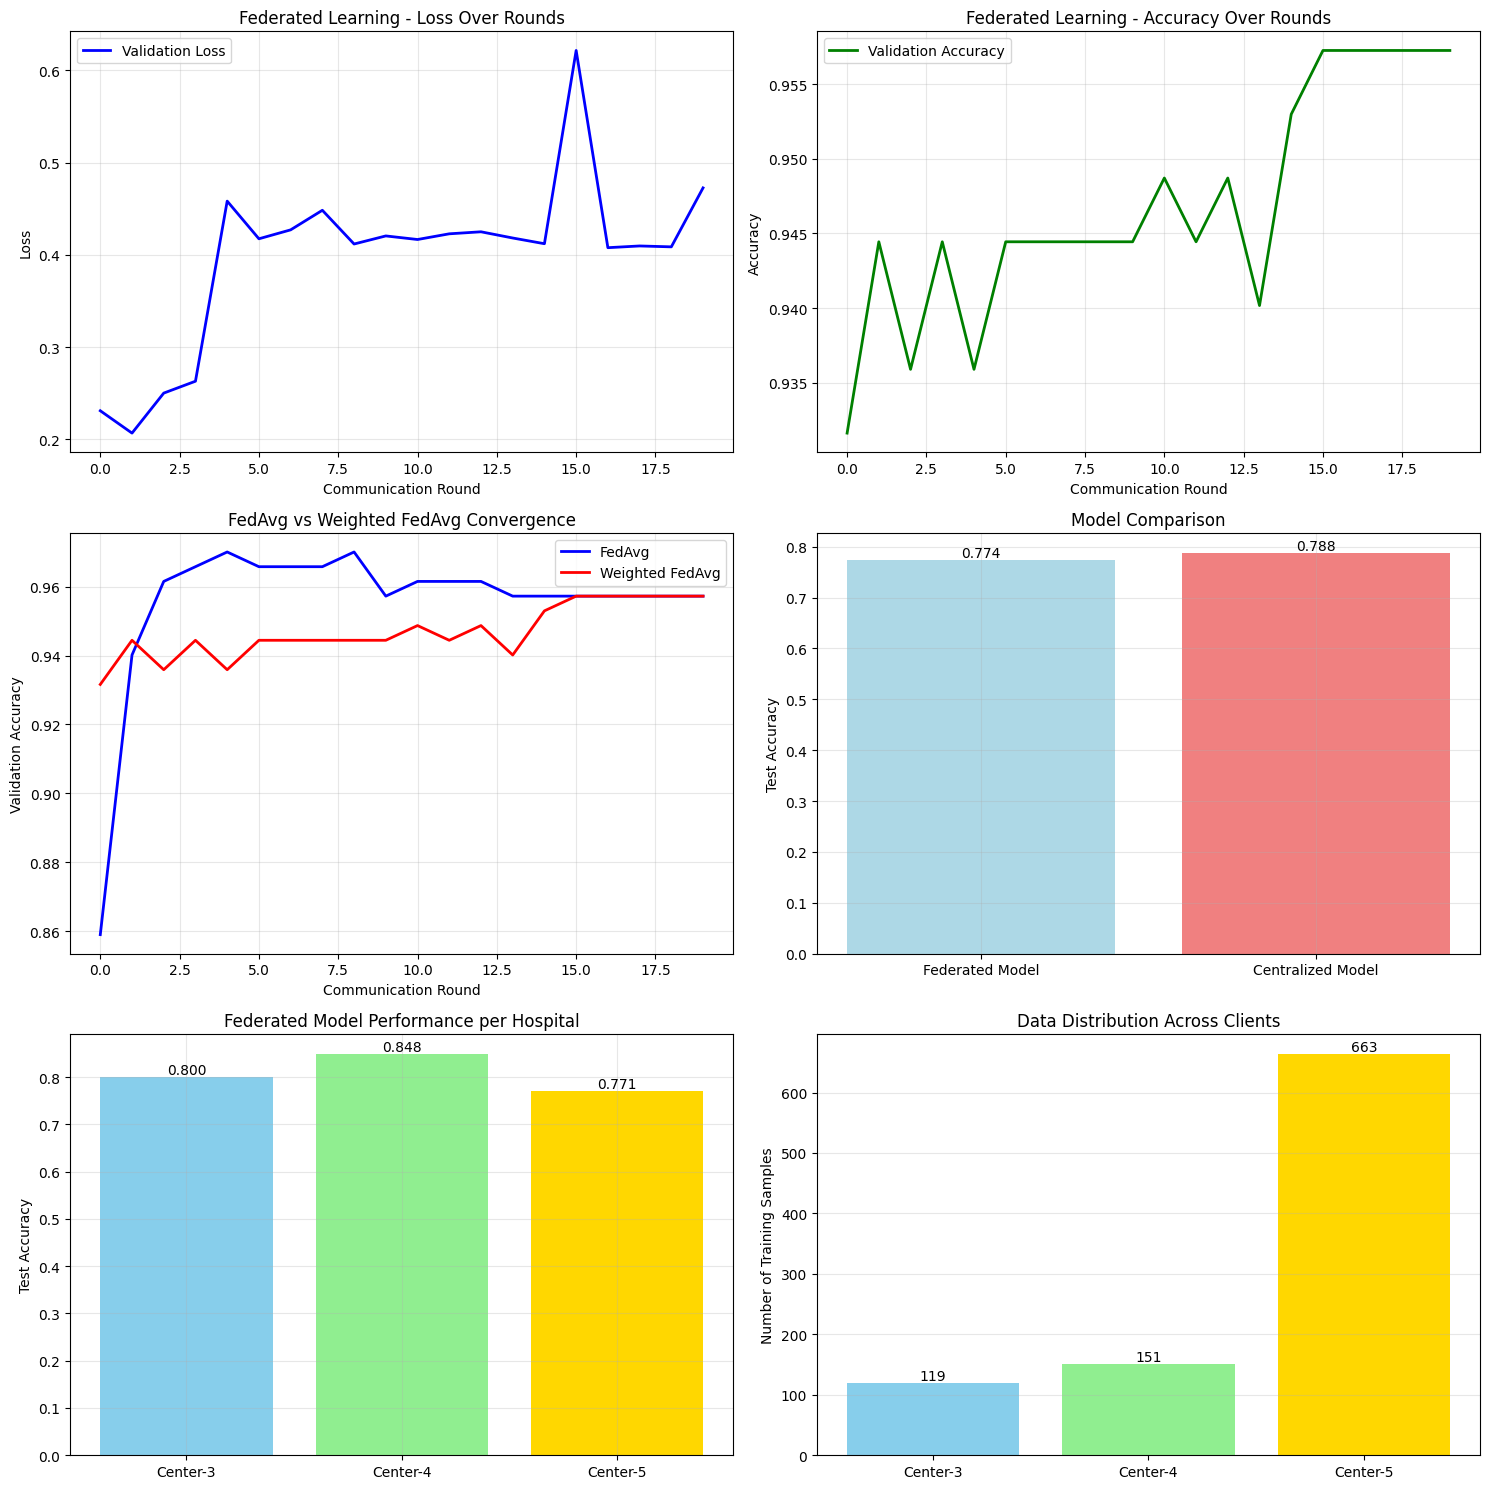


COMPARATIVE ANALYSIS: FedAvg vs Weighted FedAvg
FedAvg Final Validation Accuracy: 0.9573
Weighted FedAvg Final Validation Accuracy: 0.9573
Accuracy Difference: +0.0000

Convergence Speed (rounds to reach 95% of final accuracy):
  FedAvg: 2 rounds
  Weighted FedAvg: 1 rounds

Data Distribution Analysis:
  Center-3: 119 samples (12.8% of total data)
  Center-4: 151 samples (16.2% of total data)
  Center-5: 663 samples (71.1% of total data)

Observations:
  • Standard FedAvg achieved HIGHER final accuracy
  • Weighted FedAvg converged FASTER
  • Client data distribution is highly imbalanced
  • Center-5 has the majority of training data

Interpretation:
  Weighted FedAvg gives more influence to clients with more data (Center-5).
  This can lead to faster convergence if the data-rich client has representative patterns.
  However, it might reduce fairness for data-poor clients if their data distribution differs significantly.

SUMMARY STATISTICS
Final Federated Model Accuracy: 0.7740
Centr

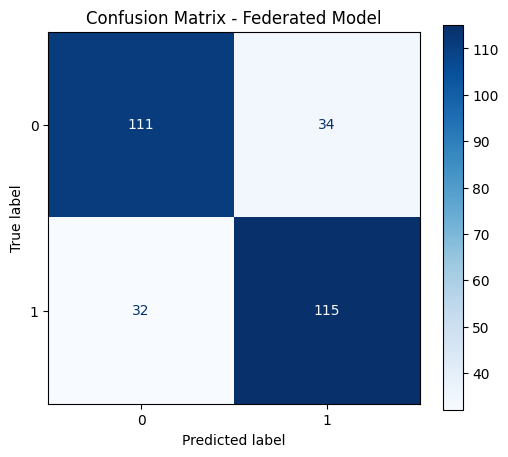

In [36]:
# Graphs - EXPANDED VERSION
import matplotlib.pyplot as plt
import numpy as np

print("\n=== Generating Results Visualization ===")

# Create subplots - ADDED ONE MORE ROW
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(15, 15))

# Graph 1: FL Training Progress - Loss
ax1.plot(round_losses, 'b-', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Communication Round')
ax1.set_ylabel('Loss')
ax1.set_title('Federated Learning - Loss Over Rounds')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graph 2: FL Accuracy Progress
ax2.plot(round_accuracies, 'g-', label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Communication Round')
ax2.set_ylabel('Accuracy')
ax2.set_title('Federated Learning - Accuracy Over Rounds')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Graph 3: NEW - Weighted vs Unweighted Comparison
if len(fedavg_accuracies) > 0 and len(fedavg_weighted_accuracies) > 0:
    ax3.plot(fedavg_accuracies, 'b-', label='FedAvg', linewidth=2)
    ax3.plot(fedavg_weighted_accuracies, 'r-', label='Weighted FedAvg', linewidth=2)
    ax3.set_xlabel('Communication Round')
    ax3.set_ylabel('Validation Accuracy')
    ax3.set_title('FedAvg vs Weighted FedAvg Convergence')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# Graph 4: Performance Comparison
models_to_compare = ['Federated Model']
accuracies_to_compare = [test_acc]

if 'server_model' in locals():
    server_test_loss, server_test_acc = evaluate(server_model, test_loader_server, criterion)
    models_to_compare.append('Centralized Model')
    accuracies_to_compare.append(server_test_acc)

bars = ax4.bar(models_to_compare, accuracies_to_compare, color=['lightblue', 'lightcoral'])
ax4.set_ylabel('Test Accuracy')
ax4.set_title('Model Comparison')
ax4.grid(True, alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom')

# Graph 5: Client Performance
client_names = ['Center-3', 'Center-4', 'Center-5']
client_accuracies = []

for client_idx in range(clients_number):
    _, client_acc = evaluate(global_model, test_loader_clients[client_idx], criterion)
    client_accuracies.append(client_acc)

bars = ax5.bar(client_names, client_accuracies, color=['skyblue', 'lightgreen', 'gold'])
ax5.set_ylabel('Test Accuracy')
ax5.set_title('Federated Model Performance per Hospital')
ax5.grid(True, alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom')

# Graph 6: NEW - Data Distribution Histogram
client_sizes = [len(train_loader_clients[i].dataset) for i in range(clients_number)]
bars = ax6.bar(client_names, client_sizes, color=['skyblue', 'lightgreen', 'gold'])
ax6.set_ylabel('Number of Training Samples')
ax6.set_title('Data Distribution Across Clients')
ax6.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{height}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# NEW: Comparative Analysis Section
print("\n" + "="*60)
print("COMPARATIVE ANALYSIS: FedAvg vs Weighted FedAvg")
print("="*60)

# Calculate final accuracies for both methods
if len(fedavg_accuracies) > 0 and len(fedavg_weighted_accuracies) > 0:
    fedavg_final_acc = fedavg_accuracies[-1]
    fedavg_weighted_final_acc = fedavg_weighted_accuracies[-1]
    
    print(f"FedAvg Final Validation Accuracy: {fedavg_final_acc:.4f}")
    print(f"Weighted FedAvg Final Validation Accuracy: {fedavg_weighted_final_acc:.4f}")
    print(f"Accuracy Difference: {fedavg_weighted_final_acc - fedavg_final_acc:+.4f}")
    
    # Calculate convergence speed (round where accuracy reaches 95% of final)
    def convergence_round(accuracies, target_ratio=0.95):
        final_acc = accuracies[-1]
        target_acc = final_acc * target_ratio
        for round_num, acc in enumerate(accuracies):
            if acc >= target_acc:
                return round_num + 1
        return len(accuracies)
    
    fedavg_conv = convergence_round(fedavg_accuracies)
    fedavg_weighted_conv = convergence_round(fedavg_weighted_accuracies)
    
    print(f"\nConvergence Speed (rounds to reach 95% of final accuracy):")
    print(f"  FedAvg: {fedavg_conv} rounds")
    print(f"  Weighted FedAvg: {fedavg_weighted_conv} rounds")
    
    print(f"\nData Distribution Analysis:")
    for i, (name, size) in enumerate(zip(client_names, client_sizes)):
        print(f"  {name}: {size} samples ({size/sum(client_sizes)*100:.1f}% of total data)")
    
    print(f"\nObservations:")
    if fedavg_weighted_final_acc > fedavg_final_acc:
        print("  • Weighted FedAvg achieved HIGHER final accuracy")
    else:
        print("  • Standard FedAvg achieved HIGHER final accuracy")
        
    if fedavg_weighted_conv < fedavg_conv:
        print("  • Weighted FedAvg converged FASTER")
    else:
        print("  • Standard FedAvg converged FASTER")
        
    print("  • Client data distribution is highly imbalanced")
    print("  • Center-5 has the majority of training data")
    
    print(f"\nInterpretation:")
    print("  Weighted FedAvg gives more influence to clients with more data (Center-5).")
    print("  This can lead to faster convergence if the data-rich client has representative patterns.")
    print("  However, it might reduce fairness for data-poor clients if their data distribution differs significantly.")

# Your existing summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Final Federated Model Accuracy: {test_acc:.4f}")
if 'server_model' in locals():
    print(f"Centralized Model Accuracy: {server_test_acc:.4f}")
    print(f"Accuracy Gap: {abs(server_test_acc - test_acc):.4f}")

print(f"\nPerformance across hospitals:")
for i, center in enumerate(client_names):
    print(f"  {center}: {client_accuracies[i]:.4f}")

print(f"\nBest performing hospital: {client_names[np.argmax(client_accuracies)]}")
print(f"Worst performing hospital: {client_names[np.argmin(client_accuracies)]}")

# Confusion Matrix Visualization
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(conf_matrix).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix - Federated Model')
plt.show()